In [1]:
import os
import sys
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch

import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd().parent))
from src.utils import get_project_root, download_preprocessed_dataset

MODEL_NAME = "cointegrated/rubert-tiny2"
BATCH_SIZE = 32
MAX_LENGTH = 512
NUM_CLASSES = 11
RANDOM_SEED = 42
EPOCH = 5

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
PROJECT_ROOT = get_project_root()
PREPROCESSED_DATASET_PATH = PROJECT_ROOT / "data" / "preprocessed" / "clean_data.parquet"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts" / "rubert_fine-tune"

os.makedirs(ARTIFACTS_PATH, exist_ok=True)

In [4]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [5]:
try:
    df = pd.read_parquet(PREPROCESSED_DATASET_PATH)
except FileNotFoundError:
    try:
        download_preprocessed_dataset()
        df = pd.read_parquet(PREPROCESSED_DATASET_PATH)
    except Exception as ex:
        print(f"Ошибка: {ex}")

In [6]:
df.head()

,news,labels,category_name,text_len,words_count,news_tfidf_ready
0,"Российские пожарные спасли детеныша косули, по...",0,Климат,1240,185,российский пожарный спасти детёныш косуля попа...
1,Житель Сахалина заметил на острове орлана — кр...,0,Климат,858,129,житель сахалин заметить остров орлан крупный х...
2,Российские заводы начнут работать по-новому ра...,0,Климат,1117,140,российский завод начать работать спасение план...
3,Неравнодушные россияне спасли слепого и глухог...,0,Климат,999,156,неравнодушный россиянин спасти слепой глухой е...
4,Специалисты предупредили граждан Британии о во...,0,Климат,1914,256,специалист предупредить гражданин британия воз...


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["news"], 
    df["labels"], 
    test_size=0.2, 
    stratify=df["labels"],
    random_state=RANDOM_SEED
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")

Train: 56700 samples
Test:  14175 samples


In [8]:
train_df = pd.DataFrame({"text": X_train, "label": y_train})
test_df = pd.DataFrame({"text": X_test, "label": y_test})

In [9]:
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.1, 
    stratify=train_df['label'],
    random_state=RANDOM_SEED
)

In [10]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True))
})
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 51030
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 5670
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 14175
    })
})

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
).to(DEVICE)

model

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trai

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(83828, 312, padding_idx=0)
      (position_embeddings): Embedding(2048, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, 

In [12]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets

Map:   0%|          | 0/51030 [00:00<?, ? examples/s]

Map:   0%|          | 0/5670 [00:00<?, ? examples/s]

Map:   0%|          | 0/14175 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 51030
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5670
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 14175
    })
})

In [13]:
training_args = TrainingArguments(
    output_dir=ARTIFACTS_PATH / "output",
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCH,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    seed=RANDOM_SEED
)
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")
    f1_weighted = f1_score(labels, predictions, average="weighted")
    
    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [16]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.530504,0.499195,0.853616,0.852037,0.851977
2,0.368982,0.413793,0.870899,0.870058,0.870324
3,0.315877,0.389497,0.874603,0.873799,0.873967
4,0.299681,0.387377,0.877601,0.876110,0.876327
5,0.302428,0.384255,0.877778,0.876337,0.876788


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.

TrainOutput(global_step=7975, training_loss=0.45888330112804065, metrics={'train_runtime': 1429.9038, 'train_samples_per_second': 178.439, 'train_steps_per_second': 5.577, 'total_flos': 1883736933120000.0, 'train_loss': 0.45888330112804065, 'epoch': 5.0})

In [17]:
trainer.save_model(ARTIFACTS_PATH / "rubert_tiny2_finetune")
tokenizer.save_pretrained(ARTIFACTS_PATH / "rubert_tiny2_finetune")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('C:\\Users\\alexa\\Desktop\\ЦК\\AIE-MIREA\\project\\artifacts\\rubert_fine-tune\\rubert_tiny2_finetune\\tokenizer_config.json',
 'C:\\Users\\alexa\\Desktop\\ЦК\\AIE-MIREA\\project\\artifacts\\rubert_fine-tune\\rubert_tiny2_finetune\\tokenizer.json')

Testing rubert_tiny2_finetuned on test set



Test Results:
  Accuracy:     0.8763
  F1-macro:     0.8754
  F1-weighted:  0.8756


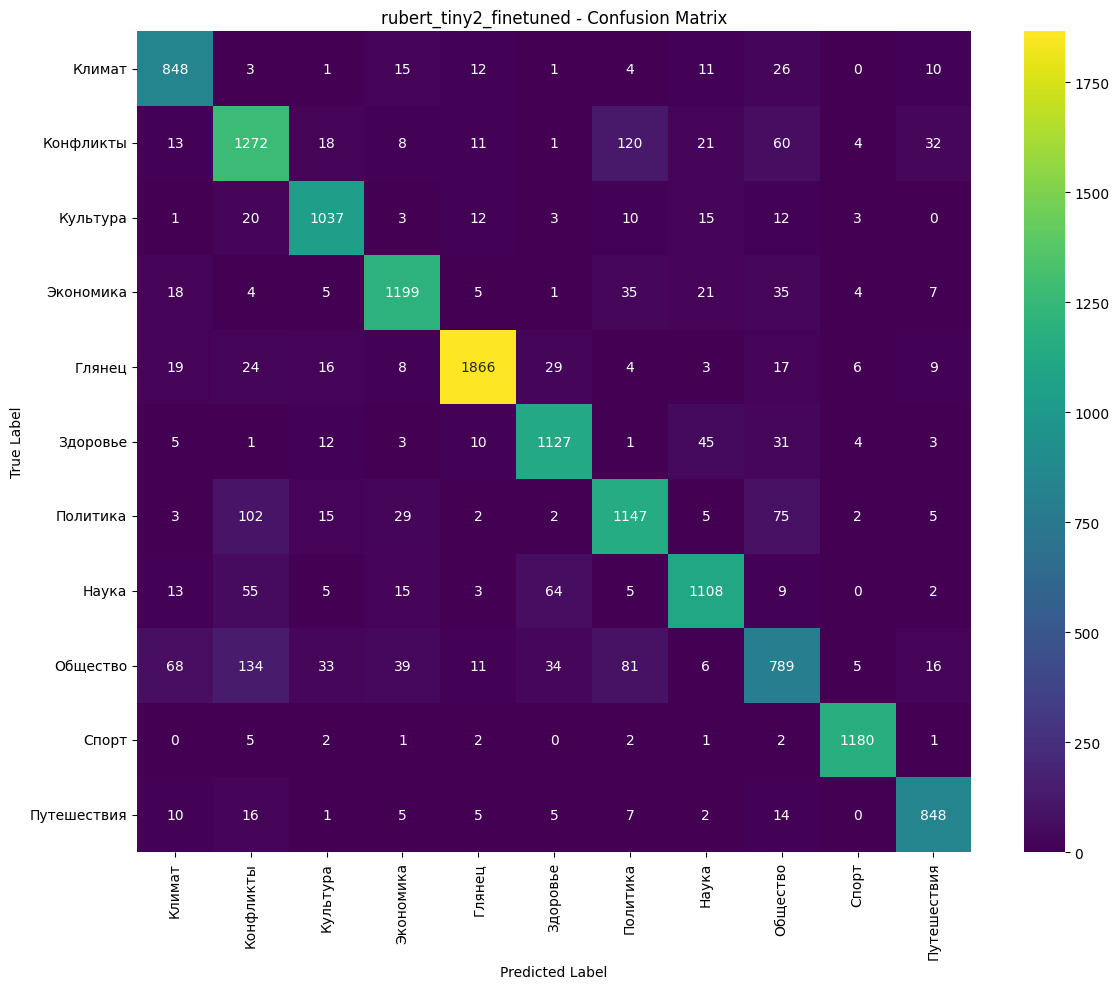

Confusion matrix saved to: C:\Users\alexa\Desktop\ЦК\AIE-MIREA\project\artifacts\rubert_fine-tune\rubert_tiny2_finetuned_confusion_matrix.png

Classification Report - rubert_tiny2_finetuned
              precision    recall  f1-score   support

      Климат       0.85      0.91      0.88       931
   Конфликты       0.78      0.82      0.80      1560
    Культура       0.91      0.93      0.92      1116
   Экономика       0.90      0.90      0.90      1334
      Глянец       0.96      0.93      0.95      2001
    Здоровье       0.89      0.91      0.90      1242
    Политика       0.81      0.83      0.82      1387
       Наука       0.89      0.87      0.88      1279
    Общество       0.74      0.65      0.69      1216
       Спорт       0.98      0.99      0.98      1196
 Путешествия       0.91      0.93      0.92       913

    accuracy                           0.88     14175
   macro avg       0.87      0.88      0.88     14175
weighted avg       0.88      0.88      0.88     1417

In [19]:
import json

def evaluate_finetuned_model(trainer, model_name, class_names, artifacts_path):
    
    """
    Оценивает fine-tuned модель на тестовом датасете
    """
    
    print("=" * 60)
    print(f"Testing {model_name} on test set")
    print("=" * 60)
    
    test_results = trainer.predict(tokenized_datasets["test"])
    
    y_pred = np.argmax(test_results.predictions, axis=-1)
    y_true = test_results.label_ids
    
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    
    print(f"\nTest Results:")
    print(f"  Accuracy:     {accuracy:.4f}")
    print(f"  F1-macro:     {f1_macro:.4f}")
    print(f"  F1-weighted:  {f1_weighted:.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(artifacts_path / f"{model_name}_confusion_matrix.png", dpi=150)
    plt.show()
    print(f"Confusion matrix saved to: {artifacts_path / f'{model_name}_confusion_matrix.png'}")
    
    print("\n" + "=" * 60)
    print(f"Classification Report - {model_name}")
    print("=" * 60)
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    class_rows = [cn for cn in class_names if cn in report_df.index]
    class_df = report_df.loc[class_rows].copy()
    class_df["support"] = class_df["support"].astype(int)
    
    out_df = class_df.reset_index().rename(columns={"index": "class"})
    out_path = artifacts_path / f"{model_name}_class_report.csv"
    out_df.to_csv(out_path, index=False)
    
    test_metrics = {
        "accuracy": float(accuracy),
        "f1_macro": float(f1_macro),
        "f1_weighted": float(f1_weighted),
        "best_epoch": training_args.num_train_epochs,
        "learning_rate": training_args.learning_rate,
        "batch_size": training_args.per_device_train_batch_size,
        "max_length": MAX_LENGTH
    }
    
    metrics_path = artifacts_path / f"{model_name}_metrics.json"
    
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(test_metrics, f, indent=2, ensure_ascii=False)
        
    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "y_pred": y_pred,
        "y_true": y_true
    }


class_names = df.groupby("labels")["category_name"].first().values
results = evaluate_finetuned_model(
    trainer=trainer,
    model_name="rubert_tiny2_finetuned",
    class_names=class_names,
    artifacts_path=ARTIFACTS_PATH
)

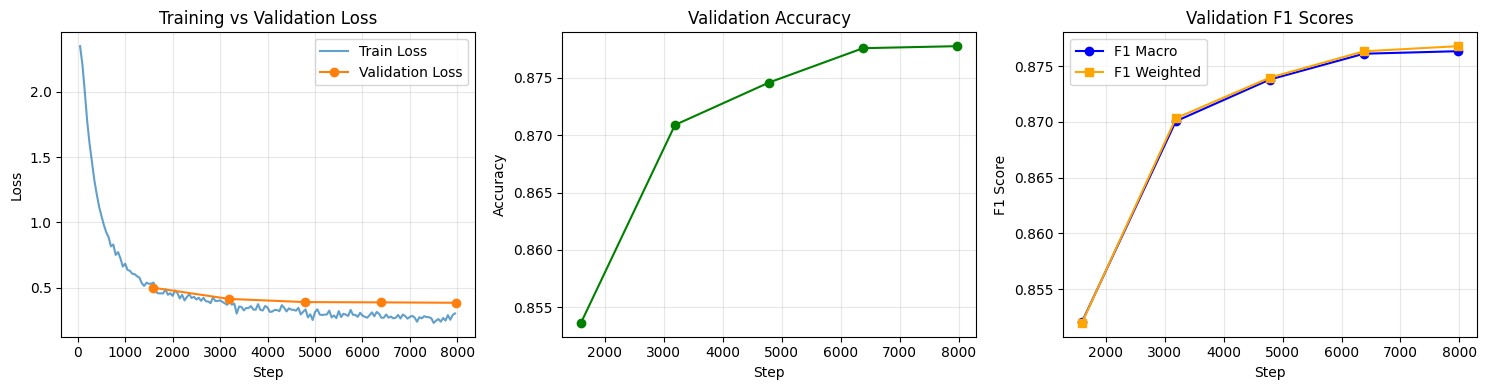

In [20]:
logs = trainer.state.log_history

train_losses = []
eval_metrics = []

for log in logs:
    if "loss" in log:
        train_losses.append({"step": log["step"], "loss": log["loss"]})
    if "eval_loss" in log:
        eval_metrics.append({
            "step": log["step"],
            "eval_loss": log["eval_loss"],
            "eval_accuracy": log.get("eval_accuracy", 0),
            "eval_f1_macro": log.get("eval_f1_macro", 0),
            "eval_f1_weighted": log.get("eval_f1_weighted", 0),
        })

train_df = pd.DataFrame(train_losses)
eval_df = pd.DataFrame(eval_metrics)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_df["step"], train_df["loss"], label="Train Loss", alpha=0.7)
axes[0].plot(eval_df["step"], eval_df["eval_loss"], label="Validation Loss", marker="o")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_df["step"], eval_df["eval_accuracy"], marker="o", color="green")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].grid(True, alpha=0.3)

axes[2].plot(eval_df["step"], eval_df["eval_f1_macro"], marker="o", label="F1 Macro", color="blue")
axes[2].plot(eval_df["step"], eval_df["eval_f1_weighted"], marker="s", label="F1 Weighted", color="orange")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("F1 Score")
axes[2].set_title("Validation F1 Scores")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "training_curves.png", dpi=150)
plt.show()